# Card Transaction Fraud Detection
## Notebook 1 — Exploratory Data Analysis: Customer & Merchant Behaviour

**Dataset:** Credit Card Transactions Fraud Detection Dataset (Sparkov simulation), Kaggle — kartik2112/fraud-detection  
**Files:** `fraudTrain.csv` (Jan 2019 – Jun 2020) and `fraudTest.csv` (Jun 2020 – Dec 2020)

**Objective of this notebook:** understand *how fraudulent card transactions differ from legitimate ones* —
by amount, merchant category, time, customer profile, geography and card-usage behaviour —
so that the findings can guide feature engineering and modelling in Notebook 2 and 3.

> EDA is done on the **training file only**. The test file is kept untouched until final model evaluation,
> so that nothing we learn from it can leak into our modelling decisions.

## 0. Setup and data loading

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR = 'data/raw'
FIG_DIR = 'outputs/figures'
TBL_DIR = 'outputs/tables'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
LEGIT_C, FRAUD_C = '#4C72B0', '#DD5555'

def save_fig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight')
    plt.show()

def save_tbl(df_, name):
    df_.to_csv(os.path.join(TBL_DIR, name))

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, 'fraudTrain.csv'),
                 parse_dates=['trans_date_trans_time', 'dob'])
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
print('Period:', df['trans_date_trans_time'].min(), '->', df['trans_date_trans_time'].max())
df.head()

Rows: 1,296,675   Columns: 22
Period: 2019-01-01 00:00:18 -> 2020-06-21 12:13:37


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.01,-82.05,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.16,-118.19,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.15,-112.15,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.03,-112.56,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.67,-78.63,0


## 1. Data overview and quality
Checking data types, missing values, duplicates and how many unique customers, merchants and categories exist.

In [4]:
import os

BASE = os.path.join(os.path.expanduser('~'), 'fraud-outputs')
FIG_DIR = os.path.join(BASE, 'figures')
TBL_DIR = os.path.join(BASE, 'tables')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

pd.DataFrame({'a': [1]}).to_csv(os.path.join(TBL_DIR, 'test.csv'))
print('Saving to:', BASE)
print('saved OK')

Saving to: C:\Users\adith\fraud-outputs
saved OK


In [5]:
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(2),
    'unique_values': df.nunique()
})
save_tbl(quality, 'eda_01_data_quality.csv')

print('Duplicate rows            :', df.duplicated().sum())
print('Duplicate transaction IDs :', df['trans_num'].duplicated().sum())
print('Unique cards (customers)  :', f"{df['cc_num'].nunique():,}")
print('Unique merchants          :', f"{df['merchant'].nunique():,}")
print('Merchant categories       :', df['category'].nunique())
print('States covered            :', df['state'].nunique())
quality

Duplicate rows            : 0
Duplicate transaction IDs : 0
Unique cards (customers)  : 983
Unique merchants          : 693
Merchant categories       : 14
States covered            : 51


,dtype,missing_count,missing_pct,unique_values
trans_date_trans_time,datetime64[us],0,0.00,1274791
cc_num,int64,0,0.00,983
merchant,str,0,0.00,693
category,str,0,0.00,14
amt,float64,0,0.00,52928
first,str,0,0.00,352
last,str,0,0.00,481
gender,str,0,0.00,2
street,str,0,0.00,983
city,str,0,0.00,894


**Note:** every merchant name in this dataset begins with the prefix `fraud_` (e.g. `fraud_Kirlin and Sons`).
This is an artefact of the data generator and says **nothing** about whether a transaction is fraudulent,
so we remove the prefix to avoid confusion.

In [6]:
df['merchant'] = df['merchant'].str.replace('^fraud_', '', regex=True)
df[['merchant', 'category', 'amt', 'is_fraud']].head()

,merchant,category,amt,is_fraud
0,"Rippin, Kub and Mann",misc_net,4.97,0
1,"Heller, Gutmann and Zieme",grocery_pos,107.23,0
2,Lind-Buckridge,entertainment,220.11,0
3,"Kutch, Hermiston and Farrell",gas_transport,45.00,0
4,Keeling-Crist,misc_pos,41.96,0


## 2. Class imbalance — why accuracy is misleading

Legitimate :  1,289,169 (99.42%)
Fraud      :      7,506 (0.58%)
Imbalance ratio: 1 fraud for every 172 legitimate transactions

A model that predicts "legitimate" for everything would be 99.42% accurate but would catch ZERO fraud.


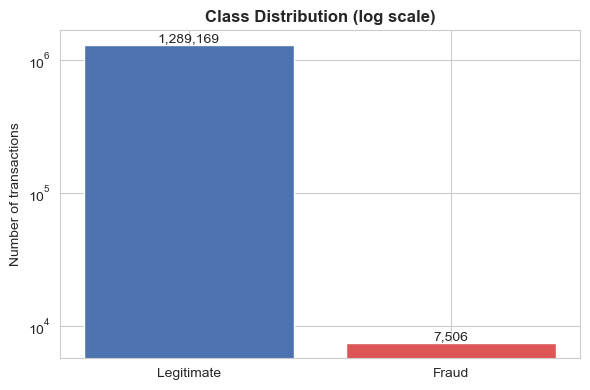

In [7]:
counts = df['is_fraud'].value_counts().sort_index()
fraud_pct = df['is_fraud'].mean() * 100

print(f'Legitimate : {counts[0]:>10,} ({100 - fraud_pct:.2f}%)')
print(f'Fraud      : {counts[1]:>10,} ({fraud_pct:.2f}%)')
print(f'Imbalance ratio: 1 fraud for every {counts[0] / counts[1]:,.0f} legitimate transactions')
print(f'\nA model that predicts "legitimate" for everything would be {100 - fraud_pct:.2f}% accurate '
      'but would catch ZERO fraud.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legitimate', 'Fraud'], counts.values, color=[LEGIT_C, FRAUD_C])
ax.set_yscale('log')
ax.set_title('Class Distribution (log scale)', fontweight='bold')
ax.set_ylabel('Number of transactions')
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
save_fig('eda_01_class_distribution.png')

## 3. Derived features for analysis
Raw columns like date of birth and latitude/longitude are not directly meaningful, so we derive:
transaction **hour**, **day of week**, **month**, customer **age**, and the **distance** between the customer's home and the merchant.

In [8]:
t = df['trans_date_trans_time']
df['hour'] = t.dt.hour
df['day_of_week'] = t.dt.day_name()
df['month'] = t.dt.to_period('M').astype(str)
df['age'] = ((t - df['dob']).dt.days / 365.25).astype(int)
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 120],
                         labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+'], right=False)

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine_km(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
df[['hour', 'day_of_week', 'month', 'age', 'age_group', 'distance_km']].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hour,"1,296,675.00",NaN,NaN,NaN,12.80,6.82,0.00,7.00,14.00,19.00,23.00
day_of_week,1296675,7,Monday,254282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,1296675,18,2019-12,141060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,"1,296,675.00",NaN,NaN,NaN,45.50,17.40,13.00,32.00,43.00,57.00,95.00
age_group,1296675,6,25-34,287749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance_km,"1,296,675.00",NaN,NaN,NaN,76.11,29.12,0.02,55.33,78.23,98.50,152.12


## 4. Transaction amount — do fraudsters spend differently?

In [9]:
amt_stats = df.groupby('is_fraud')['amt'].describe(percentiles=[.25, .5, .75, .95])
amt_stats.index = ['Legitimate', 'Fraud']
save_tbl(amt_stats, 'eda_02_amount_stats.csv')
amt_stats

,count,mean,std,min,25%,50%,75%,95%,max
Legitimate,"1,289,169.00",67.67,154.01,1.00,9.61,47.28,82.54,189.90,"28,948.90"
Fraud,"7,506.00",531.32,390.56,1.06,245.66,396.50,900.88,"1,083.99","1,376.04"


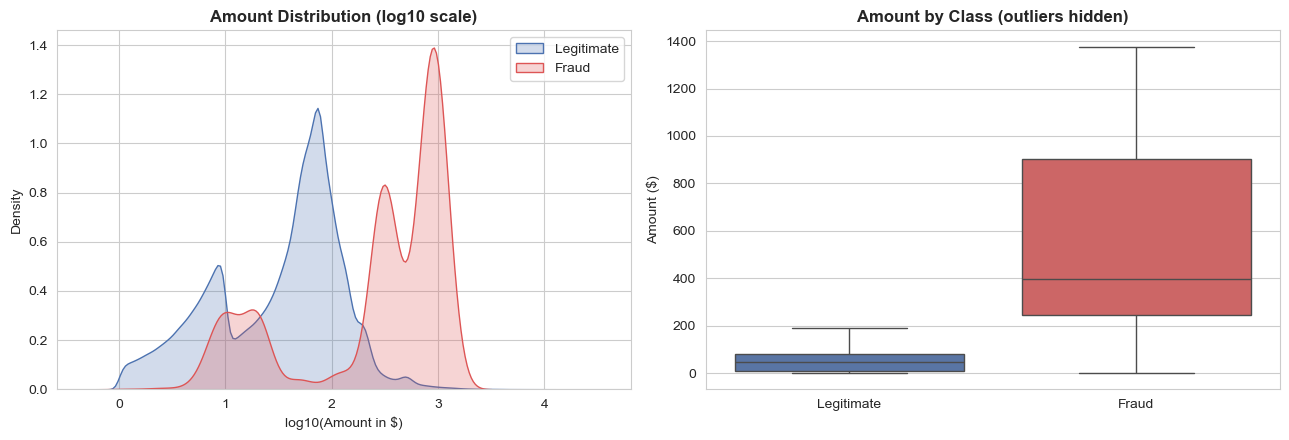

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for label, color, name in [(0, LEGIT_C, 'Legitimate'), (1, FRAUD_C, 'Fraud')]:
    sns.kdeplot(np.log10(df.loc[df['is_fraud'] == label, 'amt']), fill=True,
                color=color, label=name, common_norm=False, ax=axes[0])
axes[0].set_title('Amount Distribution (log10 scale)', fontweight='bold')
axes[0].set_xlabel('log10(Amount in $)')
axes[0].legend()

sns.boxplot(x=df['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'}), y=df['amt'],
            hue=df['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'}),
            palette={'Legitimate': LEGIT_C, 'Fraud': FRAUD_C}, legend=False,
            showfliers=False, ax=axes[1])
axes[1].set_title('Amount by Class (outliers hidden)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Amount ($)')
save_fig('eda_02_amount_distribution.png')

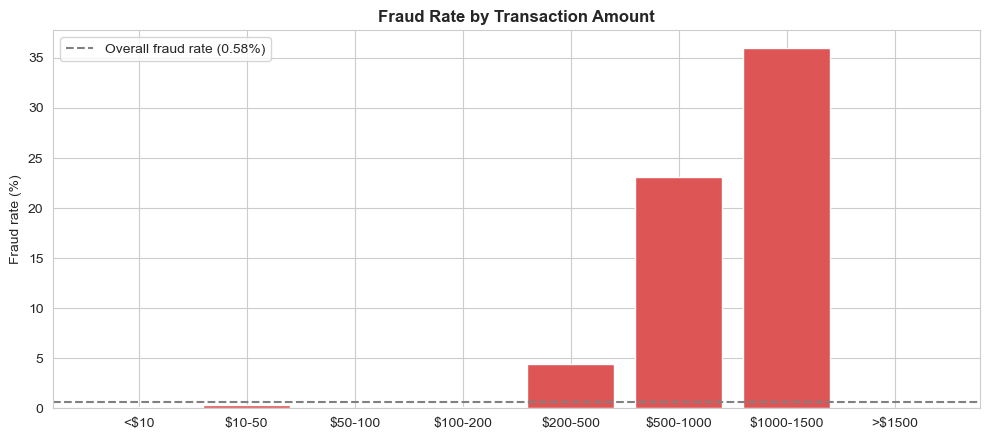

,transactions,frauds,fraud_rate_pct
amt_band,,,
<$10,335929,525,0.16
$10-50,336370,1082,0.32
$50-100,389483,45,0.01
$100-200,172969,150,0.09
$200-500,46293,2056,4.44
$500-1000,11695,2699,23.08
$1000-1500,2640,949,35.95
>$1500,1296,0,0.00


In [11]:
bins = [0, 10, 50, 100, 200, 500, 1000, 1500, np.inf]
labels = ['<$10', '$10-50', '$50-100', '$100-200', '$200-500', '$500-1000', '$1000-1500', '>$1500']
df['amt_band'] = pd.cut(df['amt'], bins=bins, labels=labels)

amt_band = df.groupby('amt_band', observed=True).agg(
    transactions=('is_fraud', 'size'), frauds=('is_fraud', 'sum'))
amt_band['fraud_rate_pct'] = amt_band['frauds'] / amt_band['transactions'] * 100
save_tbl(amt_band, 'eda_03_fraud_rate_by_amount.csv')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(amt_band.index.astype(str), amt_band['fraud_rate_pct'], color=FRAUD_C)
ax.axhline(fraud_pct, ls='--', color='grey', label=f'Overall fraud rate ({fraud_pct:.2f}%)')
ax.set_title('Fraud Rate by Transaction Amount', fontweight='bold')
ax.set_ylabel('Fraud rate (%)')
ax.legend()
save_fig('eda_03_fraud_rate_by_amount.png')
amt_band

## 5. Merchant category — where does fraud happen?

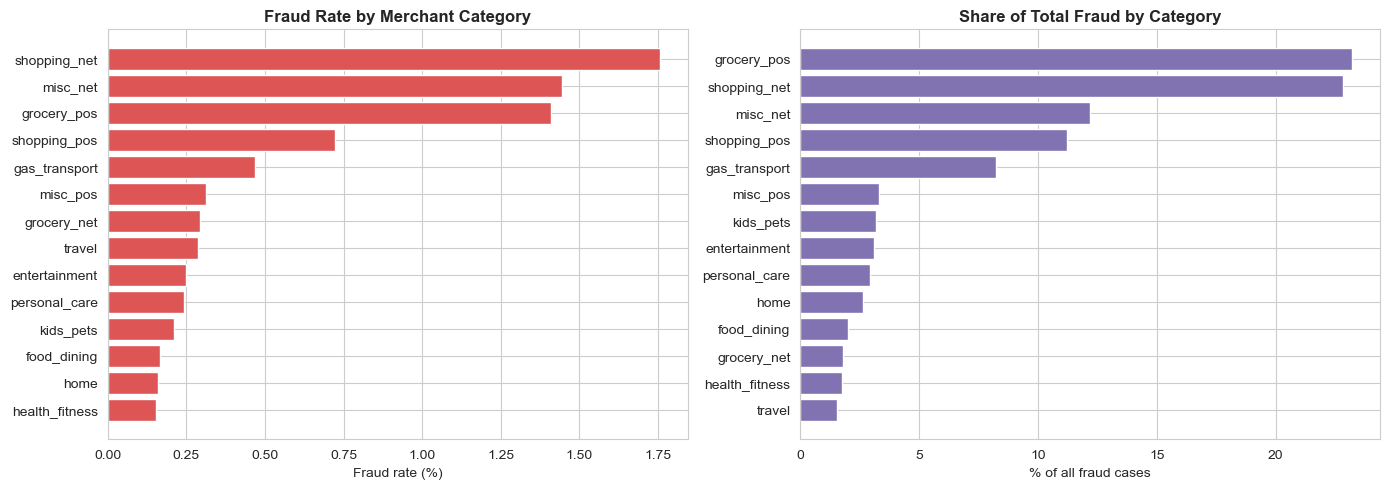

,transactions,frauds,avg_fraud_amt,fraud_rate_pct,share_of_all_fraud_pct
category,,,,,
shopping_net,97543,1713,999.25,1.76,22.82
misc_net,63287,915,797.01,1.45,12.19
grocery_pos,123638,1743,311.99,1.41,23.22
shopping_pos,116672,843,876.92,0.72,11.23
gas_transport,131659,618,12.29,0.47,8.23
misc_pos,79655,250,218.28,0.31,3.33
grocery_net,45452,134,12.16,0.29,1.79
travel,40507,116,9.06,0.29,1.55
entertainment,94014,233,503.54,0.25,3.10


In [12]:
cat = df.groupby('category').agg(
    transactions=('is_fraud', 'size'), frauds=('is_fraud', 'sum'),
    avg_fraud_amt=('amt', lambda s: s[df.loc[s.index, 'is_fraud'] == 1].mean()))
cat['fraud_rate_pct'] = cat['frauds'] / cat['transactions'] * 100
cat['share_of_all_fraud_pct'] = cat['frauds'] / cat['frauds'].sum() * 100
cat = cat.sort_values('fraud_rate_pct', ascending=False)
save_tbl(cat, 'eda_04_fraud_by_category.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cat.index, cat['fraud_rate_pct'], color=FRAUD_C)
axes[0].invert_yaxis()
axes[0].set_title('Fraud Rate by Merchant Category', fontweight='bold')
axes[0].set_xlabel('Fraud rate (%)')

cat_share = cat.sort_values('share_of_all_fraud_pct', ascending=False)
axes[1].barh(cat_share.index, cat_share['share_of_all_fraud_pct'], color='#8172B2')
axes[1].invert_yaxis()
axes[1].set_title('Share of Total Fraud by Category', fontweight='bold')
axes[1].set_xlabel('% of all fraud cases')
save_fig('eda_04_fraud_by_category.png')
cat

*Online (`_net`) vs in-store (`_pos`) categories:* compare the fraud rates above for card-not-present
(online) and card-present (point-of-sale) purchases.

## 6. Time patterns — when does fraud happen?

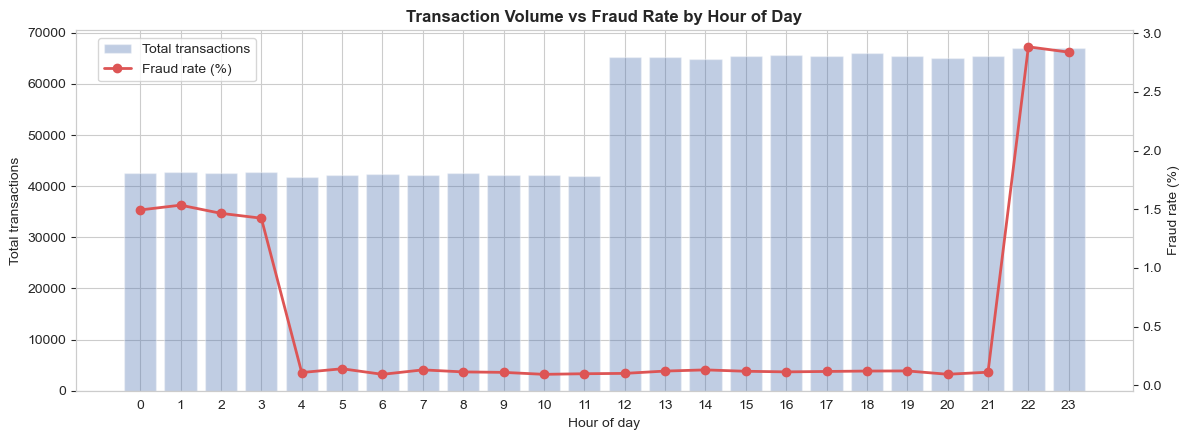

Night (10pm-4am): 23.5% of all transactions, but 84.8% of all fraud


In [13]:
hourly = df.groupby('hour').agg(transactions=('is_fraud', 'size'), frauds=('is_fraud', 'sum'))
hourly['fraud_rate_pct'] = hourly['frauds'] / hourly['transactions'] * 100
save_tbl(hourly, 'eda_05_fraud_by_hour.csv')

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.bar(hourly.index, hourly['transactions'], color=LEGIT_C, alpha=0.35, label='Total transactions')
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Total transactions')
ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly['fraud_rate_pct'], color=FRAUD_C, marker='o', lw=2, label='Fraud rate (%)')
ax2.set_ylabel('Fraud rate (%)')
ax2.grid(False)
ax1.set_xticks(range(24))
ax1.set_title('Transaction Volume vs Fraud Rate by Hour of Day', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.92))
save_fig('eda_05_fraud_by_hour.png')

night = df['hour'].isin([22, 23, 0, 1, 2, 3])
print(f'Night (10pm-4am): {night.mean()*100:.1f}% of all transactions, '
      f'but {df.loc[night, "is_fraud"].sum() / df["is_fraud"].sum() * 100:.1f}% of all fraud')

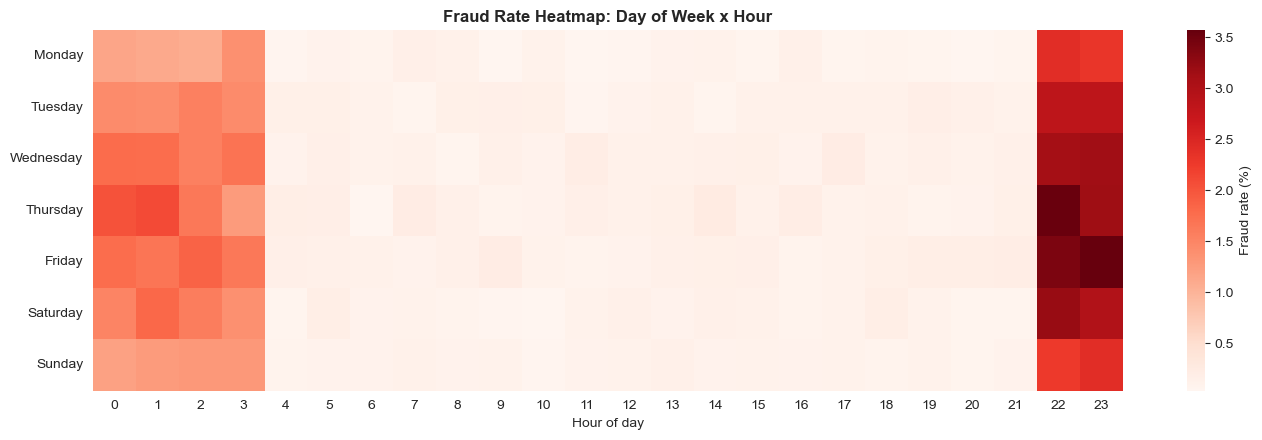

In [14]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heat = (df.pivot_table(index='day_of_week', columns='hour', values='is_fraud', aggfunc='mean') * 100
        ).reindex(day_order)
save_tbl(heat, 'eda_06_fraud_rate_day_hour.csv')

plt.figure(figsize=(14, 4.5))
sns.heatmap(heat, cmap='Reds', cbar_kws={'label': 'Fraud rate (%)'})
plt.title('Fraud Rate Heatmap: Day of Week x Hour', fontweight='bold')
plt.xlabel('Hour of day')
plt.ylabel('')
save_fig('eda_06_fraud_heatmap_day_hour.png')

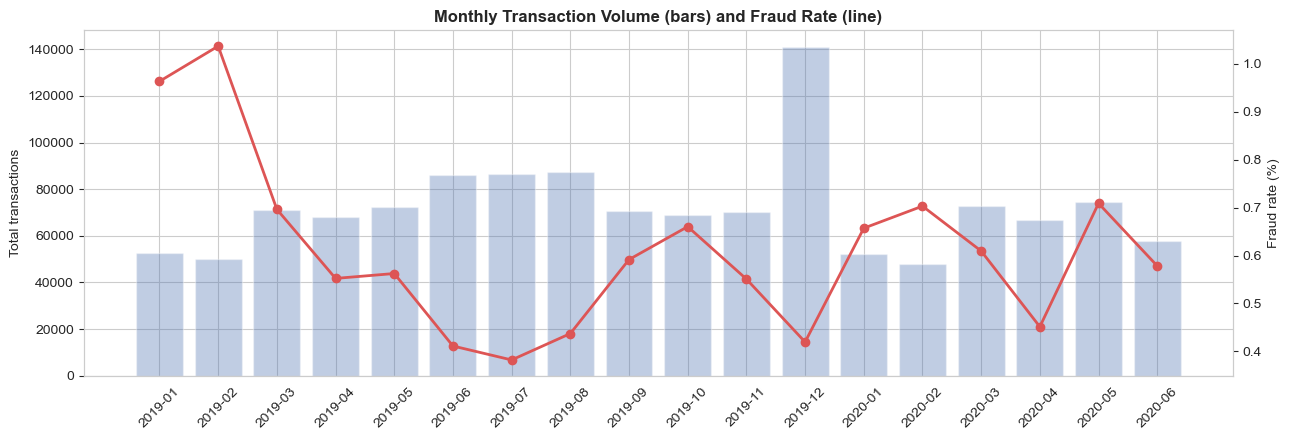

In [15]:
monthly = df.groupby('month').agg(transactions=('is_fraud', 'size'), frauds=('is_fraud', 'sum'))
monthly['fraud_rate_pct'] = monthly['frauds'] / monthly['transactions'] * 100
save_tbl(monthly, 'eda_07_fraud_by_month.csv')

fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.bar(monthly.index, monthly['transactions'], color=LEGIT_C, alpha=0.35)
ax1.set_ylabel('Total transactions')
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['fraud_rate_pct'], color=FRAUD_C, marker='o', lw=2)
ax2.set_ylabel('Fraud rate (%)')
ax2.grid(False)
ax1.set_title('Monthly Transaction Volume (bars) and Fraud Rate (line)', fontweight='bold')
save_fig('eda_07_fraud_by_month.png')

## 7. Customer profile — who is targeted?

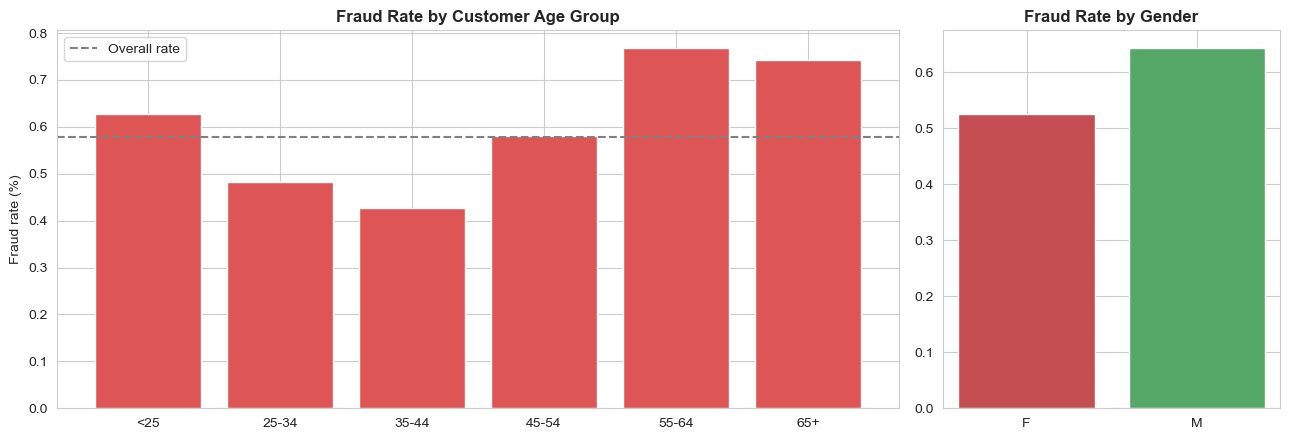

,transactions,frauds,fraud_rate_pct
age_group,,,
<25,121688,764,0.63
25-34,287749,1391,0.48
35-44,272940,1163,0.43
45-54,256553,1491,0.58
55-64,164087,1259,0.77
65+,193658,1438,0.74


,transactions,frauds,fraud_rate_pct
gender,,,
F,709863,3735,0.53
M,586812,3771,0.64


In [16]:
age_tbl = df.groupby('age_group', observed=True).agg(
    transactions=('is_fraud', 'size'), frauds=('is_fraud', 'sum'))
age_tbl['fraud_rate_pct'] = age_tbl['frauds'] / age_tbl['transactions'] * 100

gender_tbl = df.groupby('gender').agg(transactions=('is_fraud', 'size'), frauds=('is_fraud', 'sum'))
gender_tbl['fraud_rate_pct'] = gender_tbl['frauds'] / gender_tbl['transactions'] * 100

save_tbl(age_tbl, 'eda_08_fraud_by_age_group.csv')
save_tbl(gender_tbl, 'eda_09_fraud_by_gender.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios': [2.5, 1]})
axes[0].bar(age_tbl.index.astype(str), age_tbl['fraud_rate_pct'], color=FRAUD_C)
axes[0].axhline(fraud_pct, ls='--', color='grey', label='Overall rate')
axes[0].set_title('Fraud Rate by Customer Age Group', fontweight='bold')
axes[0].set_ylabel('Fraud rate (%)')
axes[0].legend()
axes[1].bar(gender_tbl.index, gender_tbl['fraud_rate_pct'], color=['#C44E52', '#55A868'])
axes[1].set_title('Fraud Rate by Gender', fontweight='bold')
save_fig('eda_08_fraud_by_customer_profile.png')
display(age_tbl, gender_tbl)

## 8. Geography — location and distance

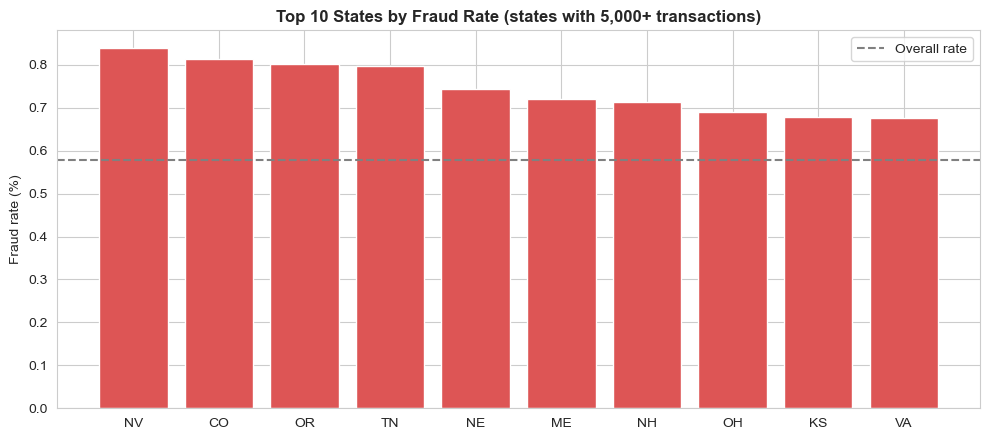

In [17]:
state = df.groupby('state').agg(transactions=('is_fraud', 'size'), frauds=('is_fraud', 'sum'))
state['fraud_rate_pct'] = state['frauds'] / state['transactions'] * 100
state_reliable = state[state['transactions'] >= 5000].sort_values('fraud_rate_pct', ascending=False)
save_tbl(state, 'eda_10_fraud_by_state.csv')

top = state_reliable.head(10)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(top.index, top['fraud_rate_pct'], color=FRAUD_C)
ax.axhline(fraud_pct, ls='--', color='grey', label='Overall rate')
ax.set_title('Top 10 States by Fraud Rate (states with 5,000+ transactions)', fontweight='bold')
ax.set_ylabel('Fraud rate (%)')
ax.legend()
save_fig('eda_09_fraud_by_state.png')

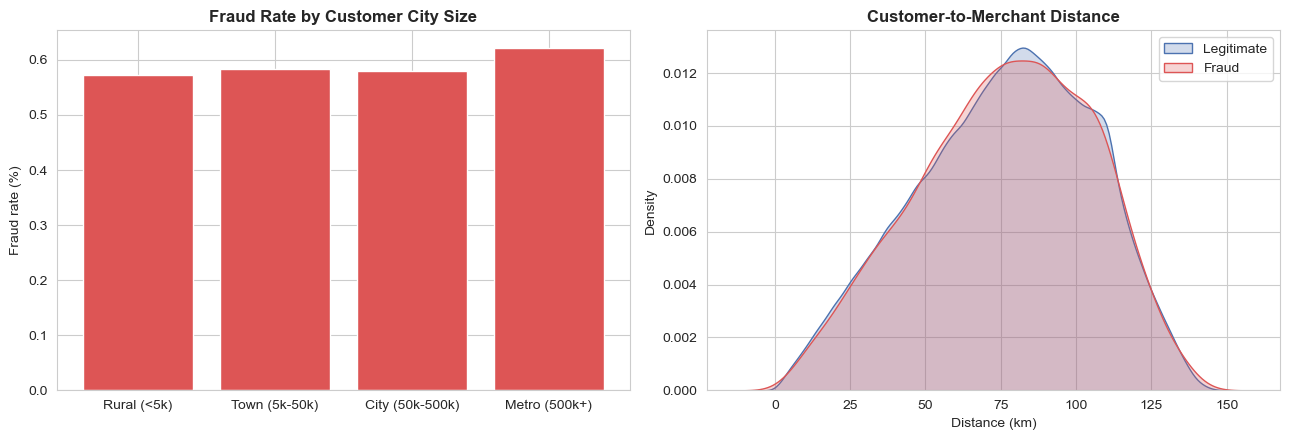

,transactions,frauds,fraud_rate_pct
city_size,,,
Rural (<5k),789219,4526,0.57
Town (5k-50k),264782,1546,0.58
City (50k-500k),176965,1025,0.58
Metro (500k+),65709,409,0.62


,count,mean,std,min,25%,50%,75%,max
Legitimate,"1,289,169.00",76.11,29.12,0.02,55.33,78.23,98.50,152.12
Fraud,"7,506.00",76.27,28.75,0.74,55.63,77.93,98.39,144.52


In [18]:
df['city_size'] = pd.cut(df['city_pop'], bins=[0, 5_000, 50_000, 500_000, np.inf],
                         labels=['Rural (<5k)', 'Town (5k-50k)', 'City (50k-500k)', 'Metro (500k+)'])
city_tbl = df.groupby('city_size', observed=True).agg(
    transactions=('is_fraud', 'size'), frauds=('is_fraud', 'sum'))
city_tbl['fraud_rate_pct'] = city_tbl['frauds'] / city_tbl['transactions'] * 100
save_tbl(city_tbl, 'eda_11_fraud_by_city_size.csv')

dist_stats = df.groupby('is_fraud')['distance_km'].describe()
dist_stats.index = ['Legitimate', 'Fraud']
save_tbl(dist_stats, 'eda_12_distance_stats.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(city_tbl.index.astype(str), city_tbl['fraud_rate_pct'], color=FRAUD_C)
axes[0].set_title('Fraud Rate by Customer City Size', fontweight='bold')
axes[0].set_ylabel('Fraud rate (%)')
for label, color, name in [(0, LEGIT_C, 'Legitimate'), (1, FRAUD_C, 'Fraud')]:
    sns.kdeplot(df.loc[df['is_fraud'] == label, 'distance_km'], color=color, label=name,
                fill=True, common_norm=False, ax=axes[1])
axes[1].set_title('Customer-to-Merchant Distance', fontweight='bold')
axes[1].set_xlabel('Distance (km)')
axes[1].legend()
save_fig('eda_10_city_size_and_distance.png')
display(city_tbl, dist_stats)

If the two distance curves overlap almost completely, distance is **not** a useful fraud signal in this data —
that is itself a finding worth reporting (a common assumption that doesn't hold here).

## 9. Card behaviour — how does a compromised card behave?
Fraud rarely happens once. We look at each card's history: how many fraud transactions a compromised card
sees, over how many days, and how quickly transactions follow each other (**velocity**).

In [19]:
df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
df['hours_since_prev'] = (df.groupby('cc_num')['trans_date_trans_time'].diff()
                          .dt.total_seconds() / 3600)

cards_total = df['cc_num'].nunique()
fraud_cards = df.loc[df['is_fraud'] == 1, 'cc_num'].unique()
print(f'Cards with at least one fraud: {len(fraud_cards):,} of {cards_total:,} '
      f'({len(fraud_cards) / cards_total * 100:.1f}%)')

burst = (df[df['is_fraud'] == 1].groupby('cc_num')
         .agg(fraud_txns=('is_fraud', 'size'),
              first=('trans_date_trans_time', 'min'),
              last=('trans_date_trans_time', 'max'),
              total_stolen=('amt', 'sum')))
burst['fraud_window_days'] = (burst['last'] - burst['first']).dt.total_seconds() / 86400
burst_summary = burst[['fraud_txns', 'fraud_window_days', 'total_stolen']].describe()
save_tbl(burst_summary, 'eda_13_fraud_burst_per_card.csv')
burst_summary

Cards with at least one fraud: 762 of 983 (77.5%)


,fraud_txns,fraud_window_days,total_stolen
count,762.00,762.00,762.00
mean,9.85,1.69,"5,233.71"
std,2.96,0.39,"2,113.31"
min,2.00,0.04,20.44
25%,8.00,1.54,"3,737.02"
50%,10.00,1.88,"5,159.15"
75%,12.00,1.93,"6,667.77"
max,19.00,2.89,"12,011.59"


Median gap since previous transaction on same card:
  Legitimate: 4.6 hours
  Fraud     : 1.4 hours


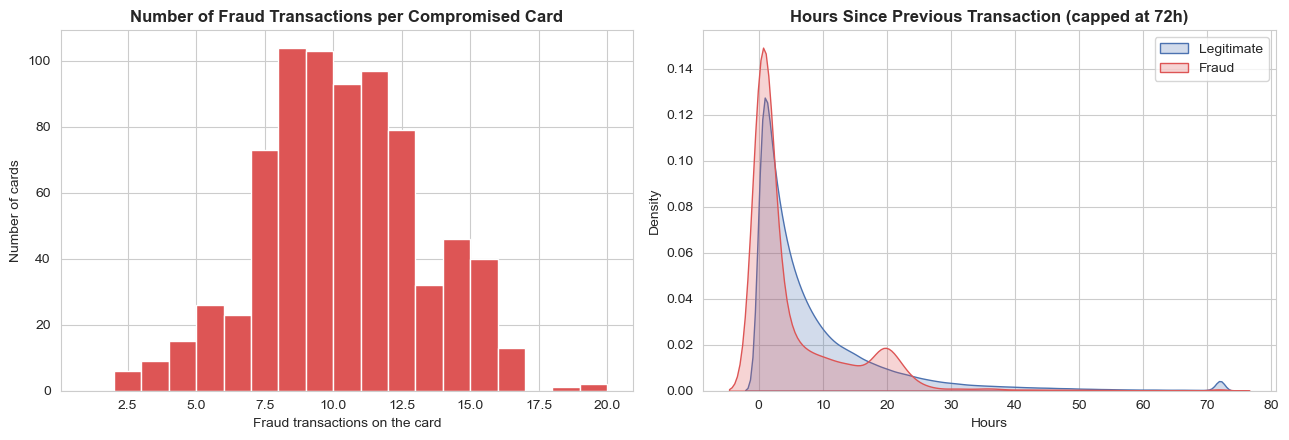

In [20]:
vel = df.groupby('is_fraud')['hours_since_prev'].median()
print(f'Median gap since previous transaction on same card:')
print(f'  Legitimate: {vel[0]:.1f} hours')
print(f'  Fraud     : {vel[1]:.1f} hours')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(burst['fraud_txns'], bins=range(1, int(burst['fraud_txns'].max()) + 2),
             color=FRAUD_C, edgecolor='white')
axes[0].set_title('Number of Fraud Transactions per Compromised Card', fontweight='bold')
axes[0].set_xlabel('Fraud transactions on the card')
axes[0].set_ylabel('Number of cards')

clip = df['hours_since_prev'].clip(upper=72)
for label, color, name in [(0, LEGIT_C, 'Legitimate'), (1, FRAUD_C, 'Fraud')]:
    sns.kdeplot(clip[df['is_fraud'] == label].dropna(), color=color, label=name,
                fill=True, common_norm=False, ax=axes[1])
axes[1].set_title('Hours Since Previous Transaction (capped at 72h)', fontweight='bold')
axes[1].set_xlabel('Hours')
axes[1].legend()
save_fig('eda_11_card_behaviour.png')

In [21]:
# Does the fraud amount look unusual for THAT customer? Compare each transaction to the card's typical spend.
card_median = df[df['is_fraud'] == 0].groupby('cc_num')['amt'].median().rename('card_median_amt')
df = df.merge(card_median, on='cc_num', how='left')
df['amt_vs_usual'] = df['amt'] / df['card_median_amt']

ratio = df.groupby('is_fraud')['amt_vs_usual'].median()
print(f'Median amount relative to the customer\'s usual spend:')
print(f'  Legitimate: {ratio[0]:.1f}x   Fraud: {ratio[1]:.1f}x')

Median amount relative to the customer's usual spend:
  Legitimate: 1.0x   Fraud: 10.1x


## 10. Merchants most exploited by fraudsters

In [22]:
merch = df.groupby(['merchant', 'category']).agg(
    transactions=('is_fraud', 'size'), frauds=('is_fraud', 'sum'))
merch['fraud_rate_pct'] = merch['frauds'] / merch['transactions'] * 100
top_merch = merch[merch['transactions'] >= 500].sort_values('frauds', ascending=False).head(15)
save_tbl(top_merch, 'eda_14_top_fraud_merchants.csv')
top_merch

,,transactions,frauds,fraud_rate_pct
merchant,category,,,
Rau and Sons,grocery_pos,2490,49,1.97
Kozey-Boehm,shopping_net,1866,48,2.57
Doyle Ltd,grocery_pos,2558,47,1.84
Vandervort-Funk,grocery_pos,2474,47,1.90
Cormier LLC,shopping_net,1959,45,2.30
Padberg-Welch,grocery_pos,2424,44,1.82
Terry-Huel,shopping_net,1996,43,2.15
Koepp-Witting,grocery_pos,2437,42,1.72
Jast Ltd,shopping_net,1953,42,2.15


## 11. Correlation of numeric features with fraud

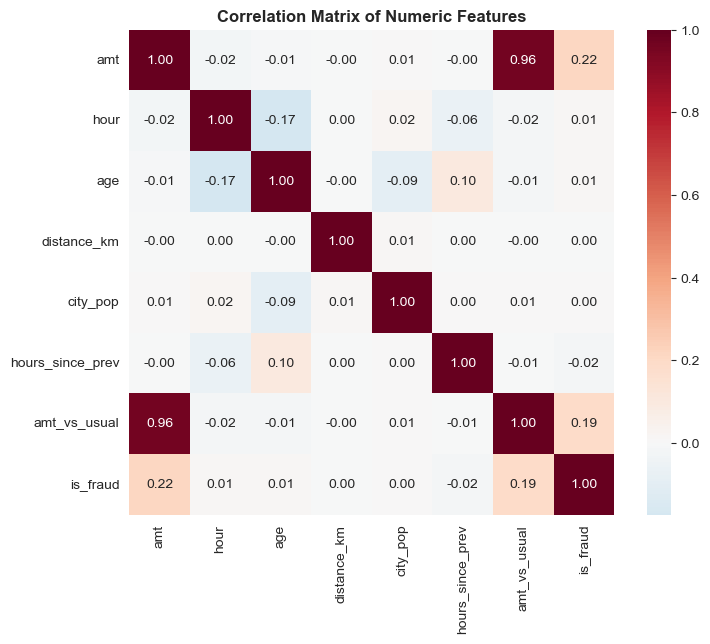

In [23]:
num_cols = ['amt', 'hour', 'age', 'distance_km', 'city_pop', 'hours_since_prev', 'amt_vs_usual', 'is_fraud']
corr = df[num_cols].corr()
save_tbl(corr, 'eda_15_correlation.csv')

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Matrix of Numeric Features', fontweight='bold')
save_fig('eda_12_correlation_matrix.png')

Correlation only captures *straight-line* relationships. A low value (e.g. for `hour`) does **not** mean the
feature is useless — the hourly chart shows a strong non-linear pattern that tree-based models can learn.

## 12. Summary of key findings

In [27]:
night = df['hour'].isin([22, 23, 0, 1, 2, 3])
top_cat = cat.index[0]
top_age = age_tbl['fraud_rate_pct'].idxmax()
peak_hour = hourly['fraud_rate_pct'].idxmax()
night_share = df.loc[night, 'is_fraud'].sum() / df['is_fraud'].sum() * 100

findings = pd.DataFrame({'Finding': [
    f'Fraud is {fraud_pct:.2f}% of transactions (1 in {counts[0] / counts[1]:,.0f}); accuracy is not a valid metric.',
    f'Median fraud amount is ${amt_stats.loc["Fraud", "50%"]:,.0f} vs ${amt_stats.loc["Legitimate", "50%"]:,.0f} for legitimate.',
    f'Highest-risk category is {top_cat} ({cat.loc[top_cat, "fraud_rate_pct"]:.2f}% fraud rate).',
    f'Fraud rate peaks at hour {peak_hour}:00; night hours (10pm-4am) hold {night_share:.0f}% of all fraud.',
    f'Most-targeted age group: {top_age} ({age_tbl.loc[top_age, "fraud_rate_pct"]:.2f}% fraud rate).',
    f'A compromised card sees a median of {burst["fraud_txns"].median():.0f} fraud transactions '
    f'within {burst["fraud_window_days"].median():.1f} days.',
    f'Fraud transactions are {ratio[1]:.1f}x the customer\'s usual spend (legitimate: {ratio[0]:.1f}x).',
    f'Median time since previous card use: {vel[1]:.1f}h for fraud vs {vel[0]:.1f}h for legitimate.',
]})
findings.index = range(1, len(findings) + 1)
save_tbl(findings, 'eda_16_key_findings.csv')
pd.set_option('display.max_colwidth', None)
findings

,Finding
1,Fraud is 0.58% of transactions (1 in 172); accuracy is not a valid metric.
2,Median fraud amount is $397 vs $47 for legitimate.
3,Highest-risk category is shopping_net (1.76% fraud rate).
4,Fraud rate peaks at hour 22:00; night hours (10pm-4am) hold 85% of all fraud.
5,Most-targeted age group: 55-64 (0.77% fraud rate).
6,A compromised card sees a median of 10 fraud transactions within 1.9 days.
7,Fraud transactions are 10.1x the customer's usual spend (legitimate: 1.0x).
8,Median time since previous card use: 1.4h for fraud vs 4.6h for legitimate.


### Implications for modelling (Notebook 2)
- Use features **derived** here: hour, age, amount relative to the customer's usual spend, time since previous transaction.
- Handle the class imbalance (class weights / SMOTE on training data only).
- Evaluate with Precision, Recall, F1, ROC-AUC and PR-AUC — never accuracy alone.
- Keep the time-based split: train on `fraudTrain.csv`, evaluate on the later `fraudTest.csv`.